Found 4684 files belonging to 3 classes.
Using 3748 files for training.
Found 4684 files belonging to 3 classes.
Using 936 files for validation.
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.__operators__.getitem_1  (None, 224, 224, 3)       0         
  (SlicingOpLambda)                                              
                                                                 
 tf.nn.bias_add_1 (TFOpLamb  (None, 224, 224, 3)       0         
 da)                                                             
                                                          

C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/118 - 203s - loss: 0.6044 - accuracy: 0.7516 - val_loss: 0.2370 - val_accuracy: 0.9188 - lr: 0.0010 - 203s/epoch - 2s/step
Epoch 2/25
118/118 - 163s - loss: 0.2474 - accuracy: 0.9072 - val_loss: 0.1562 - val_accuracy: 0.9402 - lr: 0.0010 - 163s/epoch - 1s/step
Epoch 3/25
118/118 - 162s - loss: 0.1836 - accuracy: 0.9392 - val_loss: 0.1356 - val_accuracy: 0.9541 - lr: 0.0010 - 162s/epoch - 1s/step
Epoch 4/25
118/118 - 161s - loss: 0.1408 - accuracy: 0.9538 - val_loss: 0.0978 - val_accuracy: 0.9679 - lr: 0.0010 - 161s/epoch - 1s/step
Epoch 5/25
118/118 - 162s - loss: 0.1191 - accuracy: 0.9592 - val_loss: 0.1149 - val_accuracy: 0.9594 - lr: 0.0010 - 162s/epoch - 1s/step
Epoch 6/25
118/118 - 161s - loss: 0.1003 - accuracy: 0.9725 - val_loss: 0.0750 - val_accuracy: 0.9786 - lr: 0.0010 - 161s/epoch - 1s/step
Epoch 7/25
118/118 - 162s - loss: 0.0977 - accuracy: 0.9701 - val_loss: 0.0706 - val_accuracy: 0.9797 - lr: 0.0010 - 162s/epoch - 1s/step
Epoch 8/25
118/118 - 164s - loss: 0.0793 - ac

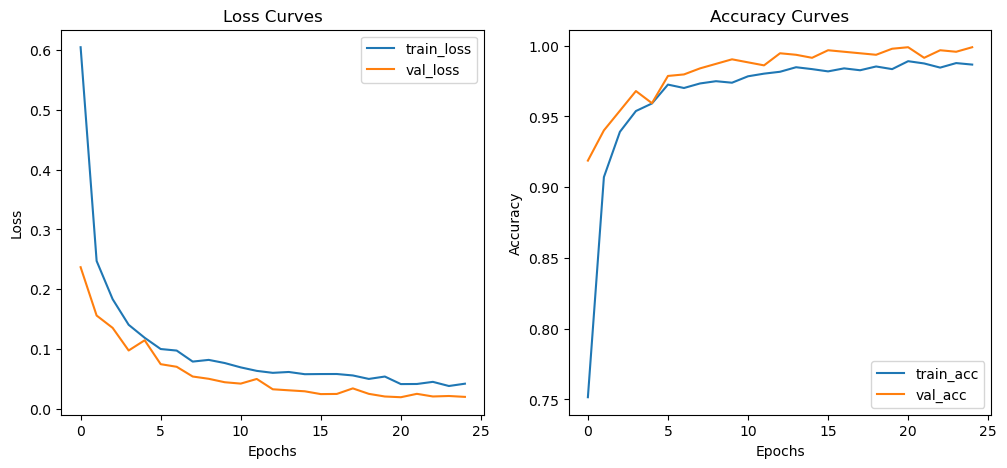


Confusion Matrix:
 [[309   0   0]
 [  0 348   0]
 [  0   1 278]]

Classification Report:
                  precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       309
      Brownspot       1.00      1.00      1.00       348
       Leafsmut       1.00      1.00      1.00       279

       accuracy                           1.00       936
      macro avg       1.00      1.00      1.00       936
   weighted avg       1.00      1.00      1.00       936



C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



✅ Model saved as rice_disease_resnet50_final.h5


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Config
# -----------------------------
DATA_DIR = r"D:\Raushan\paddy_data\rice leaf diseases dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42
EPOCHS = 25
AUTOTUNE = tf.data.AUTOTUNE
MODEL_SAVE_PATH = "rice_disease_resnet50.h5"

# -----------------------------
# Load Data (Unbalanced)
# -----------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# Data Augmentation
# -----------------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# -----------------------------
# Model: ResNet50 (transfer learning)
# -----------------------------
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
    weights="imagenet"
)
base_model.trainable = False  # freeze base layers initially

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# Callbacks
# -----------------------------
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
]

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

# -----------------------------
# Plot loss & accuracy curves
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# -----------------------------
# Evaluate model — Confusion Matrix
# -----------------------------
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# Save final model
# -----------------------------
model.save("rice_disease_resnet50_final.h5")
print("\n✅ Model saved as rice_disease_resnet50_final.h5")


In [6]:
# ==============================
# RICE DISEASE TESTING SCRIPT
# ==============================

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# ------------------------------
# Load trained model
# ------------------------------
model_path = "rice_disease_resnet50_final.h5"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ------------------------------
# Define class labels (same order used in training)
# ------------------------------
class_names = ['Bacterialblight', 'Brownspot', 'Leafsmut']

# ------------------------------
# Function to make prediction
# ------------------------------
def predict_disease(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convert to array
    img_array = image.img_to_array(img)
    
    # Normalize
    img_array = img_array / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = model.predict(img_array)
    
    # Get predicted class
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions[0])
    
    print(f"🩺 Predicted Class: {predicted_class}")
    print(f"📊 Confidence: {confidence*100:.2f}%")
    
    return predicted_class, confidence

# ------------------------------
# Example Test
# ------------------------------
img_path = r"D:\Raushan\paddy_data\rice leaf diseases dataset\Brownspot\brownspot_rotated_012.jpg"

predicted_class, confidence = predict_disease(img_path)


✅ Model loaded successfully!
1/1 [==============================] - 1s 774ms/step
🩺 Predicted Class: Leafsmut
📊 Confidence: 99.91%
